In [1]:
from sklearn.datasets import load_iris
import pandas as pd

# Load data
iris = load_iris()
X = iris.data
y = iris.target  # True labels (optional, for comparison)
df = pd.DataFrame(X, columns=iris.feature_names)
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [3]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)

# Predicted clusters
clusters = kmeans.labels_
print(clusters)

[1 2 2 2 1 1 1 1 2 2 1 1 2 2 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 2 2 1 1 1 2 2 1
 1 2 1 1 2 2 1 1 2 1 2 1 1 0 0 0 0 0 0 0 2 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]


In [4]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y, clusters))

[[ 0 33 17]
 [46  0  4]
 [50  0  0]]


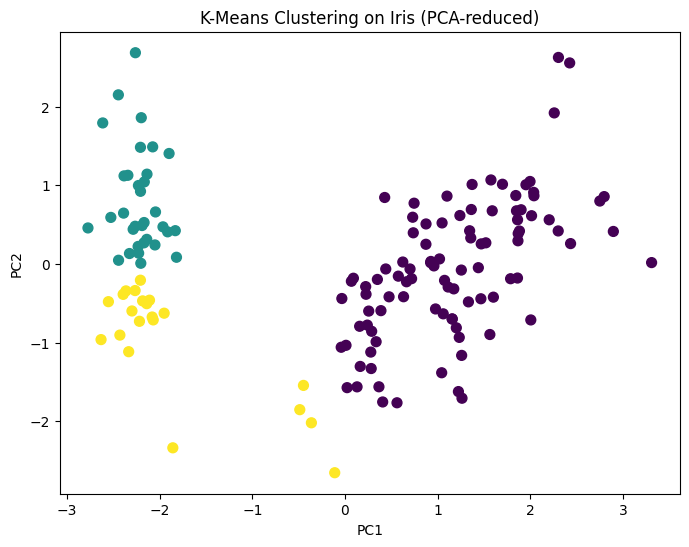

In [5]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis', s=50)
plt.title('K-Means Clustering on Iris (PCA-reduced)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

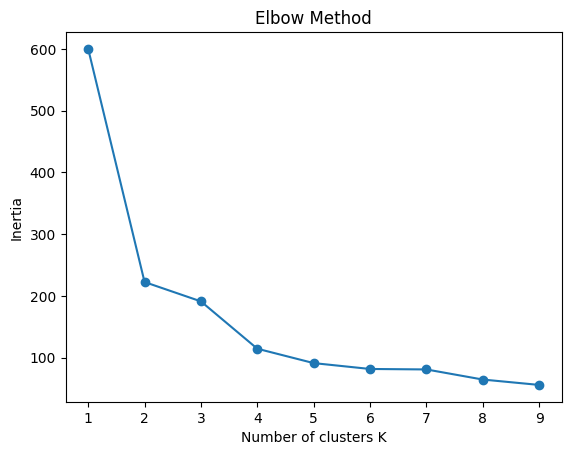

In [6]:
inertia_list = []
K_range = range(1,10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia_list.append(kmeans.inertia_)

plt.plot(K_range, inertia_list, marker='o')
plt.xlabel('Number of clusters K')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

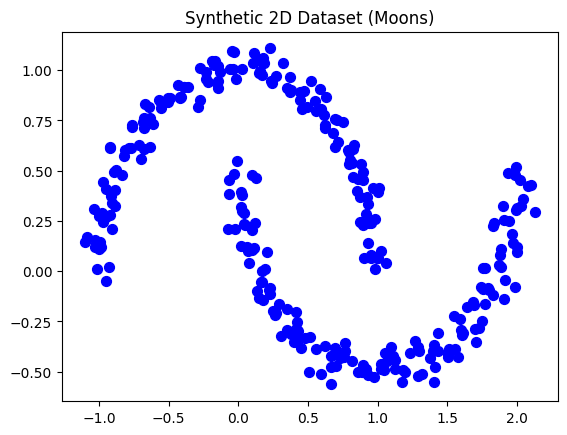

In [7]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

# Generate data
X, y = make_moons(n_samples=300, noise=0.05, random_state=42)

# Visualize
plt.scatter(X[:,0], X[:,1], c='blue', s=50)
plt.title("Synthetic 2D Dataset (Moons)")
plt.show()

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
from sklearn.cluster import DBSCAN
import numpy as np

dbscan = DBSCAN(eps=0.3, min_samples=5)
clusters = dbscan.fit_predict(X_scaled)
print(np.unique(clusters))

[0 1]


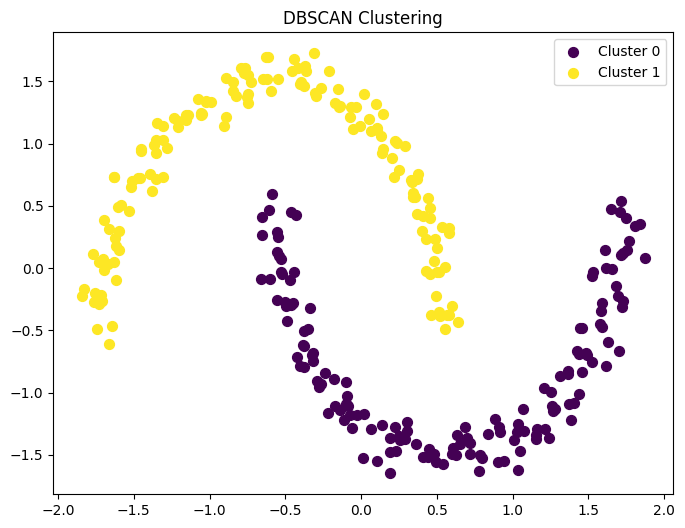

In [10]:
plt.figure(figsize=(8,6))
for cluster in np.unique(clusters):
    if cluster == -1:
        color = 'black'  # outliers
        label = 'Outlier'
    else:
        color = plt.cm.viridis(cluster / max(clusters))
        label = f'Cluster {cluster}'
    
    plt.scatter(X_scaled[clusters==cluster, 0],
                X_scaled[clusters==cluster, 1],
                c=[color], label=label, s=50)
plt.legend()
plt.title("DBSCAN Clustering")
plt.show()

In [11]:
from sklearn.datasets import load_wine
import pandas as pd

wine = load_wine()
X = wine.data
y = wine.target

print(X.shape)

(178, 13)


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(178, 2)


In [14]:
print(pca.explained_variance_ratio_)
print(sum(pca.explained_variance_ratio_))

[0.36198848 0.1920749 ]
0.5540633835693526


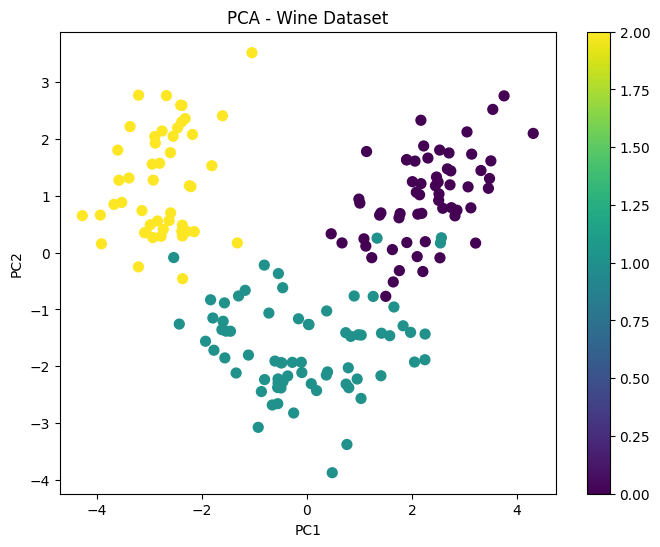

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='viridis', s=50)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA - Wine Dataset')
plt.colorbar()
plt.show()

In [16]:
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(178, 10)


In [17]:
from sklearn.datasets import load_digits

digits = load_digits()
X = digits.data   # 64 features (8x8 image)
y = digits.target

print(X.shape)

(1797, 64)


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [19]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

print(X_tsne.shape)

(1797, 2)


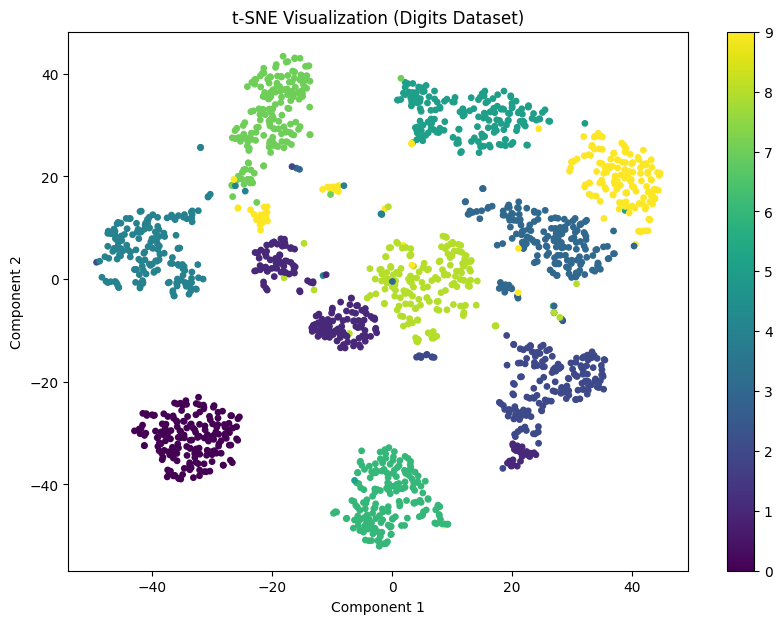

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))
scatter = plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y, cmap='viridis', s=15)

plt.colorbar(scatter)
plt.title("t-SNE Visualization (Digits Dataset)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

In [21]:
TSNE(perplexity=5)
TSNE(perplexity=50)

,"n_components n_components: int, default=2Dimension of the embedded space.",2
,"perplexity perplexity: float, default=30.0The perplexity is related to the number of nearest neighbors thatis used in other manifold learning algorithms. Larger datasetsusually require a larger perplexity. Consider selecting a valuebetween 5 and 50. Different values can result in significantlydifferent results. The perplexity must be less than the numberof samples.",50
,"early_exaggeration early_exaggeration: float, default=12.0Controls how tight natural clusters in the original space are inthe embedded space and how much space will be between them. Forlarger values, the space between natural clusters will be largerin the embedded space. Again, the choice of this parameter is notvery critical. If the cost function increases during initialoptimization, the early exaggeration factor or the learning ratemight be too high.",12.0
,"learning_rate learning_rate: float or ""auto"", default=""auto""The learning rate for t-SNE is usually in the range [10.0, 1000.0]. Ifthe learning rate is too high, the data may look like a 'ball' with anypoint approximately equidistant from its nearest neighbours. If thelearning rate is too low, most points may look compressed in a densecloud with few outliers. If the cost function gets stuck in a bad localminimum increasing the learning rate may help.Note that many other t-SNE implementations (bhtsne, FIt-SNE, openTSNE,etc.) use a definition of learning_rate that is 4 times smaller thanours. So our learning_rate=200 corresponds to learning_rate=800 inthose other implementations. The 'auto' option sets the learning_rateto `max(N / early_exaggeration / 4, 50)` where N is the sample size,following [4] and [5]... versionchanged:: 1.2 The default value changed to `""auto""`.",'auto'
,"max_iter max_iter: int, default=1000Maximum number of iterations for the optimization. Should be atleast 250... versionchanged:: 1.5 Parameter name changed from `n_iter` to `max_iter`.",1000
,"n_iter_without_progress n_iter_without_progress: int, default=300Maximum number of iterations without progress before we abort theoptimization, used after 250 initial iterations with earlyexaggeration. Note that progress is only checked every 50 iterations sothis value is rounded to the next multiple of 50... versionadded:: 0.17 parameter *n_iter_without_progress* to control stopping criteria.",300
,"min_grad_norm min_grad_norm: float, default=1e-7If the gradient norm is below this threshold, the optimization willbe stopped.",1e-07
,"metric metric: str or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string, it must be one of the optionsallowed by scipy.spatial.distance.pdist for its metric parameter, ora metric listed in pairwise.PAIRWISE_DISTANCE_FUNCTIONS.If metric is ""precomputed"", X is assumed to be a distance matrix.Alternatively, if metric is a callable function, it is called on eachpair of instances (rows) and the resulting value recorded. The callableshould take two arrays from X as input and return a value indicatingthe distance between them. The default is ""euclidean"" which isinterpreted as squared euclidean distance.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 1.1",None
,"init init: {""random"", ""pca""} or ndarray of shape (n_samples, n_components), default=""pca""Initialization of embedding.PCA initialization cannot be used with precomputed distances and isusually more globally stable than random initialization... versionchanged:: 1.2 The default value changed to `""pca""`.",'pca'
,"verbose verbose: int, default=0Verbosity level.",0


In [22]:
from sklearn.decomposition import PCA

pca = PCA(n_components=30)
X_pca = pca.fit_transform(X_scaled)

tsne = TSNE(n_components=2)
X_tsne = tsne.fit_transform(X_pca)

In [23]:
from sklearn.datasets import load_digits

digits = load_digits()
X = digits.data
y = digits.target

print(X.shape)

(1797, 64)


In [24]:
from sklearn.datasets import load_digits

digits = load_digits()
X = digits.data
y = digits.target

print(X.shape)

(1797, 64)


In [25]:
from sklearn.decomposition import PCA

pca = PCA(n_components=30)   # reduce 64 → 30
X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(1797, 30)


In [26]:
print(sum(pca.explained_variance_ratio_))

0.8932084382449572


In [27]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_pca)

print(X_tsne.shape)

(1797, 2)


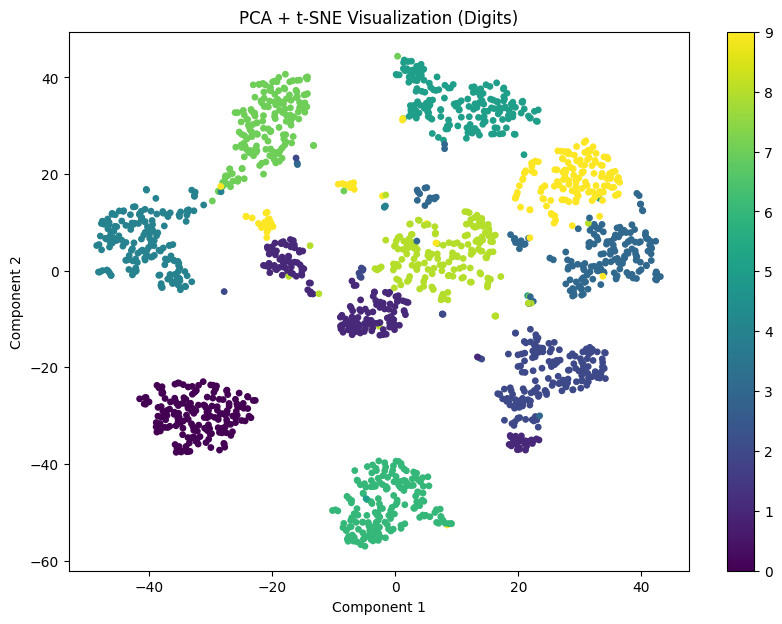

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))
scatter = plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y, cmap='viridis', s=15)

plt.colorbar(scatter)
plt.title("PCA + t-SNE Visualization (Digits)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

In [29]:
PCA(n_components=10)
PCA(n_components=50)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",50
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD

In [30]:
TSNE(perplexity=5)
TSNE(perplexity=50)

,"n_components n_components: int, default=2Dimension of the embedded space.",2
,"perplexity perplexity: float, default=30.0The perplexity is related to the number of nearest neighbors thatis used in other manifold learning algorithms. Larger datasetsusually require a larger perplexity. Consider selecting a valuebetween 5 and 50. Different values can result in significantlydifferent results. The perplexity must be less than the numberof samples.",50
,"early_exaggeration early_exaggeration: float, default=12.0Controls how tight natural clusters in the original space are inthe embedded space and how much space will be between them. Forlarger values, the space between natural clusters will be largerin the embedded space. Again, the choice of this parameter is notvery critical. If the cost function increases during initialoptimization, the early exaggeration factor or the learning ratemight be too high.",12.0
,"learning_rate learning_rate: float or ""auto"", default=""auto""The learning rate for t-SNE is usually in the range [10.0, 1000.0]. Ifthe learning rate is too high, the data may look like a 'ball' with anypoint approximately equidistant from its nearest neighbours. If thelearning rate is too low, most points may look compressed in a densecloud with few outliers. If the cost function gets stuck in a bad localminimum increasing the learning rate may help.Note that many other t-SNE implementations (bhtsne, FIt-SNE, openTSNE,etc.) use a definition of learning_rate that is 4 times smaller thanours. So our learning_rate=200 corresponds to learning_rate=800 inthose other implementations. The 'auto' option sets the learning_rateto `max(N / early_exaggeration / 4, 50)` where N is the sample size,following [4] and [5]... versionchanged:: 1.2 The default value changed to `""auto""`.",'auto'
,"max_iter max_iter: int, default=1000Maximum number of iterations for the optimization. Should be atleast 250... versionchanged:: 1.5 Parameter name changed from `n_iter` to `max_iter`.",1000
,"n_iter_without_progress n_iter_without_progress: int, default=300Maximum number of iterations without progress before we abort theoptimization, used after 250 initial iterations with earlyexaggeration. Note that progress is only checked every 50 iterations sothis value is rounded to the next multiple of 50... versionadded:: 0.17 parameter *n_iter_without_progress* to control stopping criteria.",300
,"min_grad_norm min_grad_norm: float, default=1e-7If the gradient norm is below this threshold, the optimization willbe stopped.",1e-07
,"metric metric: str or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string, it must be one of the optionsallowed by scipy.spatial.distance.pdist for its metric parameter, ora metric listed in pairwise.PAIRWISE_DISTANCE_FUNCTIONS.If metric is ""precomputed"", X is assumed to be a distance matrix.Alternatively, if metric is a callable function, it is called on eachpair of instances (rows) and the resulting value recorded. The callableshould take two arrays from X as input and return a value indicatingthe distance between them. The default is ""euclidean"" which isinterpreted as squared euclidean distance.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 1.1",None
,"init init: {""random"", ""pca""} or ndarray of shape (n_samples, n_components), default=""pca""Initialization of embedding.PCA initialization cannot be used with precomputed distances and isusually more globally stable than random initialization... versionchanged:: 1.2 The default value changed to `""pca""`.",'pca'
,"verbose verbose: int, default=0Verbosity level.",0


In [31]:
import pandas as pd

dataset = [
    ['Milk', 'Bread', 'Butter'],
    ['Bread', 'Butter'],
    ['Milk', 'Bread'],
    ['Milk', 'Butter'],
    ['Bread', 'Butter']
]

df = pd.DataFrame(dataset)
print(df)

       0       1       2
0   Milk   Bread  Butter
1  Bread  Butter     NaN
2   Milk   Bread     NaN
3   Milk  Butter     NaN
4  Bread  Butter     NaN


In [32]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_data = te.fit(dataset).transform(dataset)

df_encoded = pd.DataFrame(te_data, columns=te.columns_)
print(df_encoded)

   Bread  Butter   Milk
0   True    True   True
1   True    True  False
2   True   False   True
3  False    True   True
4   True    True  False


In [33]:
from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(df_encoded, min_support=0.4, use_colnames=True)

print(frequent_itemsets)

   support                    itemsets
0      0.8          frozenset({Bread})
1      0.8         frozenset({Butter})
2      0.6           frozenset({Milk})
3      0.6  frozenset({Bread, Butter})
4      0.4    frozenset({Milk, Bread})
5      0.4   frozenset({Milk, Butter})


In [34]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.7)

print(rules)

           antecedents          consequents  antecedent support  \
0   frozenset({Bread})  frozenset({Butter})                 0.8   
1  frozenset({Butter})   frozenset({Bread})                 0.8   

   consequent support  support  confidence    lift  representativity  \
0                 0.8      0.6        0.75  0.9375               1.0   
1                 0.8      0.6        0.75  0.9375               1.0   

   leverage  conviction  zhangs_metric  jaccard  certainty  kulczynski  
0     -0.04         0.8          -0.25      0.6      -0.25        0.75  
1     -0.04         0.8          -0.25      0.6      -0.25        0.75  


In [35]:
rules = rules.sort_values(by='lift', ascending=False)
print(rules[['antecedents','consequents','support','confidence','lift']])

           antecedents          consequents  support  confidence    lift
0   frozenset({Bread})  frozenset({Butter})      0.6        0.75  0.9375
1  frozenset({Butter})   frozenset({Bread})      0.6        0.75  0.9375
